[1/4] 加载数据...
数据加载完成，X形状: (54256, 510), y形状: (54256,)

[2/4] 特征工程...
方差筛选后特征数: 53
PCA降维后特征数: 30
解释方差比例: 0.99

[3/4] 模型训练...

训练 Logistic Regression...


/home/ma-user/anaconda3/envs/Pytorch-1.0.0/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:1228: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = -1.
  " = {}.".format(self.n_jobs))


Logistic Regression | AP: 0.6878 | 耗时: 0.56s

训练 Decision Tree...
Decision Tree | AP: 0.5787 | 耗时: 0.66s

训练 Random Forest...
Random Forest | AP: 0.6574 | 耗时: 14.44s

[4/4] 绘制PR曲线...


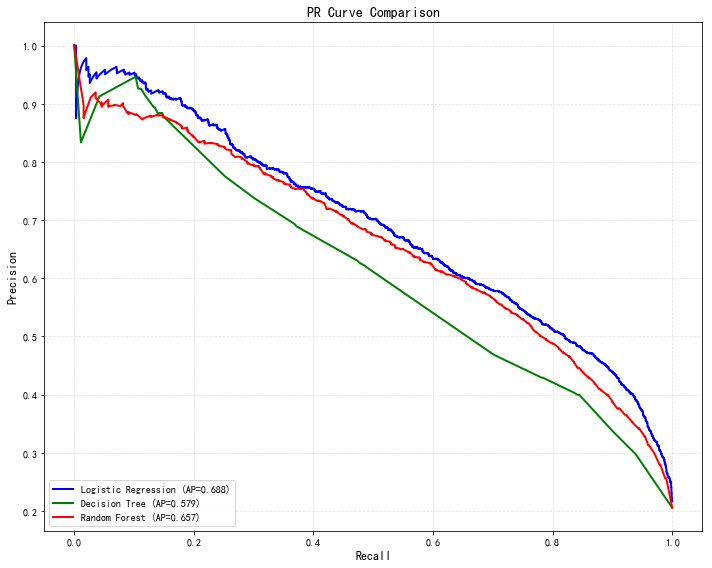

结果已保存为 pr_comparison.png

总运行时间: 31.32秒


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score

# 设置随机种子
np.random.seed(0)

def load_data():
    """加载数据并添加异常值处理"""
    try:
        X = np.loadtxt('./data/data/X_train', delimiter=',', skiprows=1, usecols=range(1,511))
        y = np.loadtxt('./data/data/Y_train', delimiter=',', skiprows=1, usecols=1)
        print(f"数据加载完成，X形状: {X.shape}, y形状: {y.shape}")
        return X, y
    except Exception as e:
        print(f"数据加载失败: {str(e)}")
        raise

class FeatureProcessor:
    def __init__(self):
        self.var_threshold = VarianceThreshold(threshold=0.1)
        self.scaler = StandardScaler()
      
        self.pca = PCA(n_components=0.95, svd_solver='full')
    
    def fit_transform(self, X):
        """稳健的特征处理流程"""
        try:
            # 1. 方差筛选
            X = self.var_threshold.fit_transform(X)
            print(f"方差筛选后特征数: {X.shape[1]}")
            
            # 2. 标准化（处理异常值）
            X = self.scaler.fit_transform(X)
            X = np.clip(X, -10, 10)  # 截断极端值
            
            # 3. 动态调整PCA组件数
            if X.shape[1] > 1:  # 至少需要2个特征才能做PCA
                if X.shape[1] > 100:  # 高维数据使用比例降维
                    self.pca.n_components = 0.95
                else:  # 低维数据使用固定组件数
                    self.pca.n_components = min(30, X.shape[1]-1)
                
                X = self.pca.fit_transform(X)
                print(f"PCA降维后特征数: {X.shape[1]}")
                print(f"解释方差比例: {self.pca.explained_variance_ratio_.sum():.2f}")
            else:
                print("特征数过少，跳过PCA")
            
            return X
        except Exception as e:
            print(f"特征处理失败: {str(e)}")
            return X  # 返回未变换的数据作为保底
    
    def transform(self, X):
        """应用相同的变换"""
        X = self.var_threshold.transform(X)
        X = self.scaler.transform(X)
        X = np.clip(X, -10, 10)
        if hasattr(self.pca, 'n_components_'):
            return self.pca.transform(X)
        return X

def train_and_evaluate(models, X_train, X_test, y_train, y_test):
    """训练评估模型"""
    results = {}
    for name, model in models.items():
        print(f"\n训练 {name}...")
        try:
            start = time()
            model.fit(X_train, y_train)
            train_time = time() - start
            
            if hasattr(model, 'predict_proba'):
                y_scores = model.predict_proba(X_test)[:, 1]
            else:
                y_scores = model.decision_function(X_test)
            
            precision, recall, _ = precision_recall_curve(y_test, y_scores)
            ap = average_precision_score(y_test, y_scores)
            
            results[name] = {
                'precision': precision,
                'recall': recall,
                'ap': ap,
                'train_time': train_time
            }
            print(f"{name} | AP: {ap:.4f} | 耗时: {train_time:.2f}s")
        except Exception as e:
            print(f"{name} 训练失败: {str(e)}")
    return results

def main():
    try:
        # 1. 加载数据
        print("[1/4] 加载数据...")
        X, y = load_data()
        
        # 2. 划分数据集
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y)
        
        # 3. 特征工程（带异常处理）
        print("\n[2/4] 特征工程...")
        processor = FeatureProcessor()
        X_train_processed = processor.fit_transform(X_train)
        X_test_processed = processor.transform(X_test)
        
        # 4. 定义模型
        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, n_jobs=-1),
            'Decision Tree': DecisionTreeClassifier(max_depth=5),
            'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1)
        }
        
        # 5. 训练评估
        print("\n[3/4] 模型训练...")
        results = train_and_evaluate(models, X_train_processed, X_test_processed, y_train, y_test)
        
        # 6. 可视化
        if results:
            print("\n[4/4] 绘制PR曲线...")
            plt.figure(figsize=(10, 8))
            colors = ['b', 'g', 'r']
            
            for (name, result), color in zip(results.items(), colors):
                plt.plot(result['recall'], result['precision'], color=color,
                       label=f"{name} (AP={result['ap']:.3f})", linewidth=2)
            
            plt.xlabel('Recall', fontsize=12)
            plt.ylabel('Precision', fontsize=12)
            plt.title('PR Curve Comparison', fontsize=14)
            plt.grid(True, linestyle='--', alpha=0.3)
            plt.legend(loc='lower left')
            plt.tight_layout()
            
            plt.savefig('pr_comparison.png', dpi=150)
            plt.show()
            print("结果已保存为 pr_comparison.png")
        else:
            print("没有有效的模型结果可供可视化")
            
    except Exception as e:
        print(f"主程序出错: {str(e)}")

if __name__ == "__main__":
    start = time()
    main()
    print(f"\n总运行时间: {time() - start:.2f}秒")